# **Insurance Claim Fraud Detection**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

In [4]:
data = pd.read_csv(r'C:\Users\Paras\Desktop\Projects\Insurance Claim Fraud Detection\data\insurance_claims.csv')
data.head(5)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,10/17/2014,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,6/27/2006,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,9/6/2000,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,5/25/1990,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,6/6/2014,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [6]:
data.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', '_c39'],
      dtype='object')

In [7]:
data['authorities_contacted'] = data['authorities_contacted'].fillna('Unknown')

In [8]:
data[['police_report_available','property_damage','collision_type']] = data[['police_report_available','property_damage','collision_type']].replace('?','Unknown')

'?' means the information is missing or not recorded. Replacing it with 'Unknown' keeps the row, avoids data loss, and lets the model learn that the information was unavailable instead of guessing.

In [9]:
data['authorities_contacted'].isnull().sum()

np.int64(0)

In [10]:
# Converting date columns to datetime format
data['policy_bind_date'] = pd.to_datetime(data['policy_bind_date'], errors='coerce', format='%m/%d/%Y')
data['incident_date'] = pd.to_datetime(data['incident_date'], errors='coerce', format='%m/%d/%Y')

# Confirm conversion
data[['policy_bind_date', 'incident_date']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   policy_bind_date  1000 non-null   datetime64[ns]
 1   incident_date     1000 non-null   datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 15.8 KB


In [11]:
data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,Unknown,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [12]:
data = data.drop(['_c39','insured_zip','policy_number','incident_location','auto_model','auto_make'],axis=1)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_bind_date             1000 non-null   datetime64[ns]
 3   policy_state                 1000 non-null   object        
 4   policy_csl                   1000 non-null   object        
 5   policy_deductable            1000 non-null   int64         
 6   policy_annual_premium        1000 non-null   float64       
 7   umbrella_limit               1000 non-null   int64         
 8   insured_sex                  1000 non-null   object        
 9   insured_education_level      1000 non-null   object        
 10  insured_occupation           1000 non-null   object        
 11  insured_hobbies              1000 non-null  

## Exploratory Data Analysis

Text(0, 0.5, 'Count')

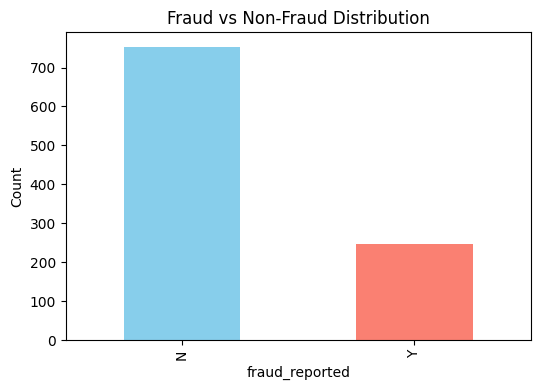

In [14]:
plt.figure(figsize=(6,4))
data['fraud_reported'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title('Fraud vs Non-Fraud Distribution')
plt.ylabel('Count')

**Insight:** This graph shows how many claims are fraudulent vs legitimate. If one bar is much taller than the other, it means the data is imbalanced - there are far more honest claims than fraudulent ones. This is why we will use SMOTE later to balance the data so the model doesn't just predict "no fraud" for everything.

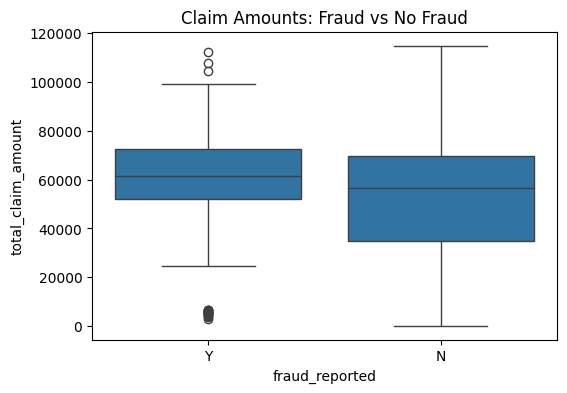

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(data=data, x=data['fraud_reported'], y=data['total_claim_amount'])
plt.title('Claim Amounts: Fraud vs No Fraud')
plt.show()

**Insight:** This graph compares the claim amounts between fraudulent and legitimate claims using a box plot. If the fraud box is higher than the non-fraud box, it means people who commit fraud tend to claim higher amounts. This feature is important because fraudsters might try to steal more money than honest claimants.

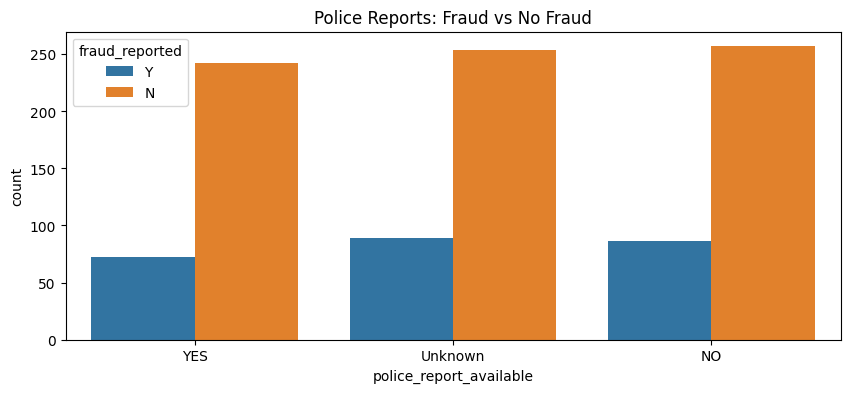

In [16]:
plt.figure(figsize=(10,4))
sns.countplot(data=data, x=data['police_report_available'], hue=data['fraud_reported'])
plt.title('Police Reports: Fraud vs No Fraud')
plt.show()

**Insight:** This graph shows whether fraud cases are more likely to have a police report or not. If fraudulent claims have fewer police reports compared to legitimate ones, it suggests fraudsters might avoid reporting to authorities. This is a useful pattern to help detect fraud.

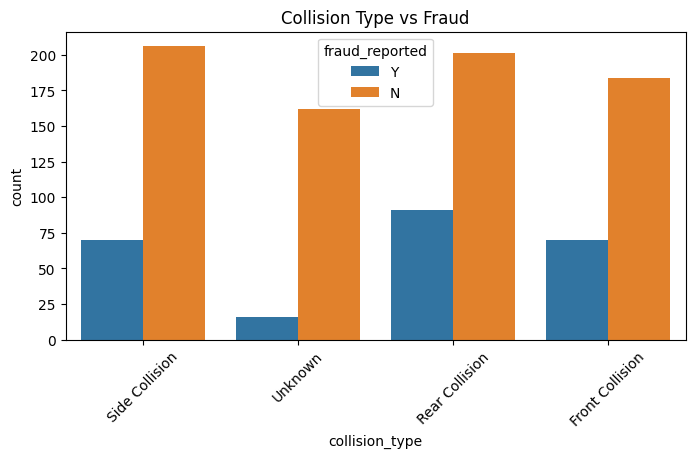

In [17]:
plt.figure(figsize=(8,4))
sns.countplot(data=data, x='collision_type', hue='fraud_reported')
plt.title('Collision Type vs Fraud')
plt.xticks(rotation=45)
plt.show()

**Insight:** This graph shows which types of collisions are associated with fraud. Some collision types might have higher fraud rates than others. For example, rear-end collisions might be easier to fake than head-on collisions, so we might see more fraud in certain collision types.

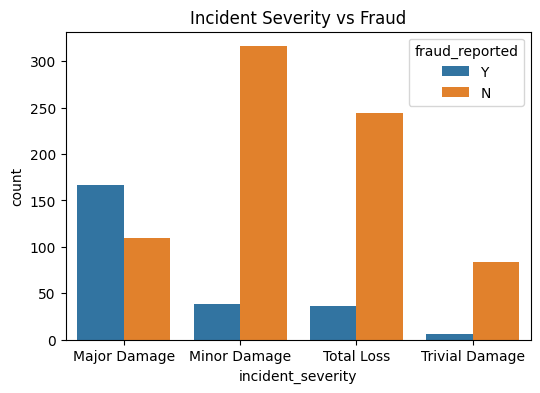

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='incident_severity', hue='fraud_reported')
plt.title('Incident Severity vs Fraud')
plt.show()

**Insight:** This graph compares fraud rates across different severity levels (minor, major, severe). If fraud is more common in certain severity levels, it tells us that fraudsters might target specific types of incidents to make their claims look more believable.

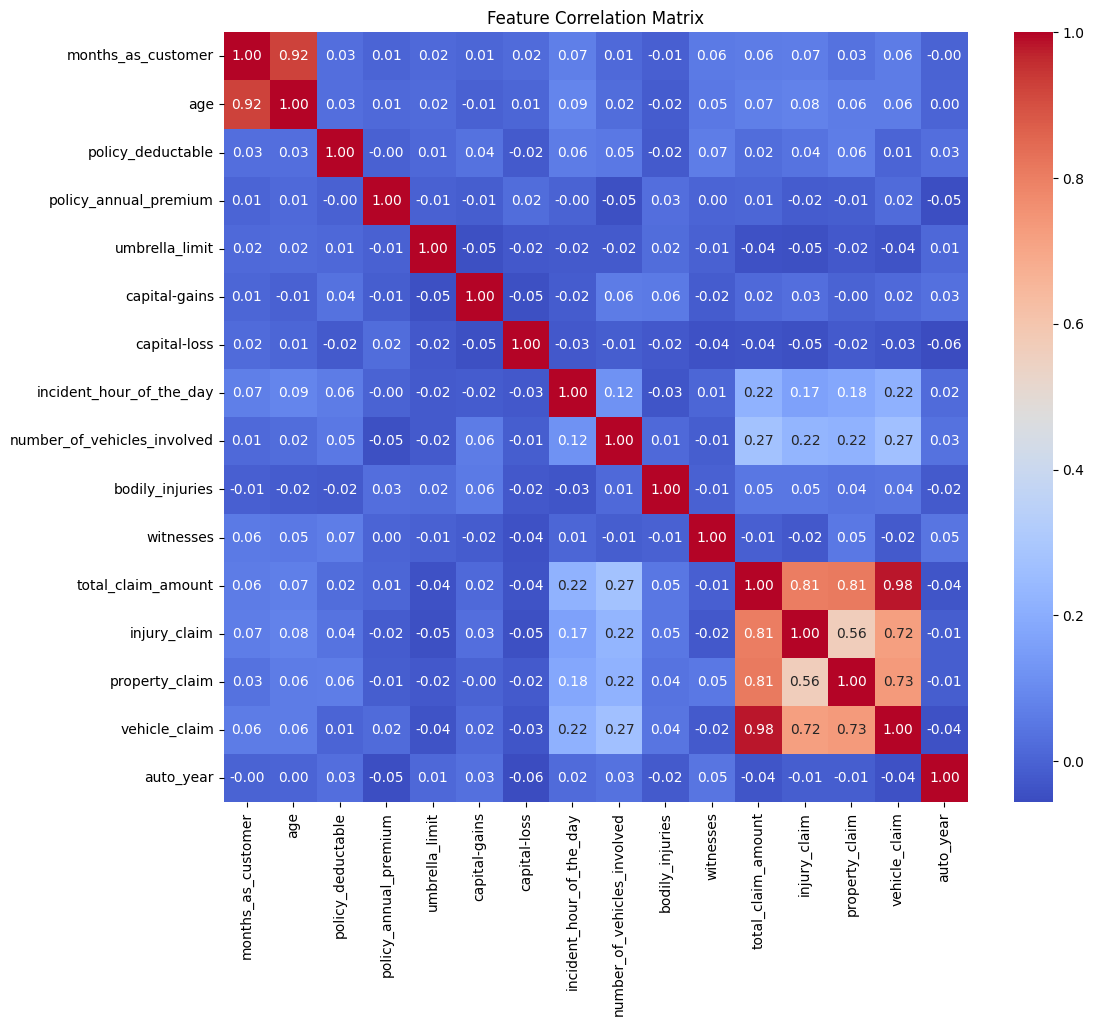

In [19]:
# Selecting only numeric columns for correlation
numeric_df = data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

**Insight:** This heat map shows how different features relate to each other. Darker colors mean features are strongly connected - if two features always go up and down together, the model might not need both. Strong connections between features and fraud are most important for detection.

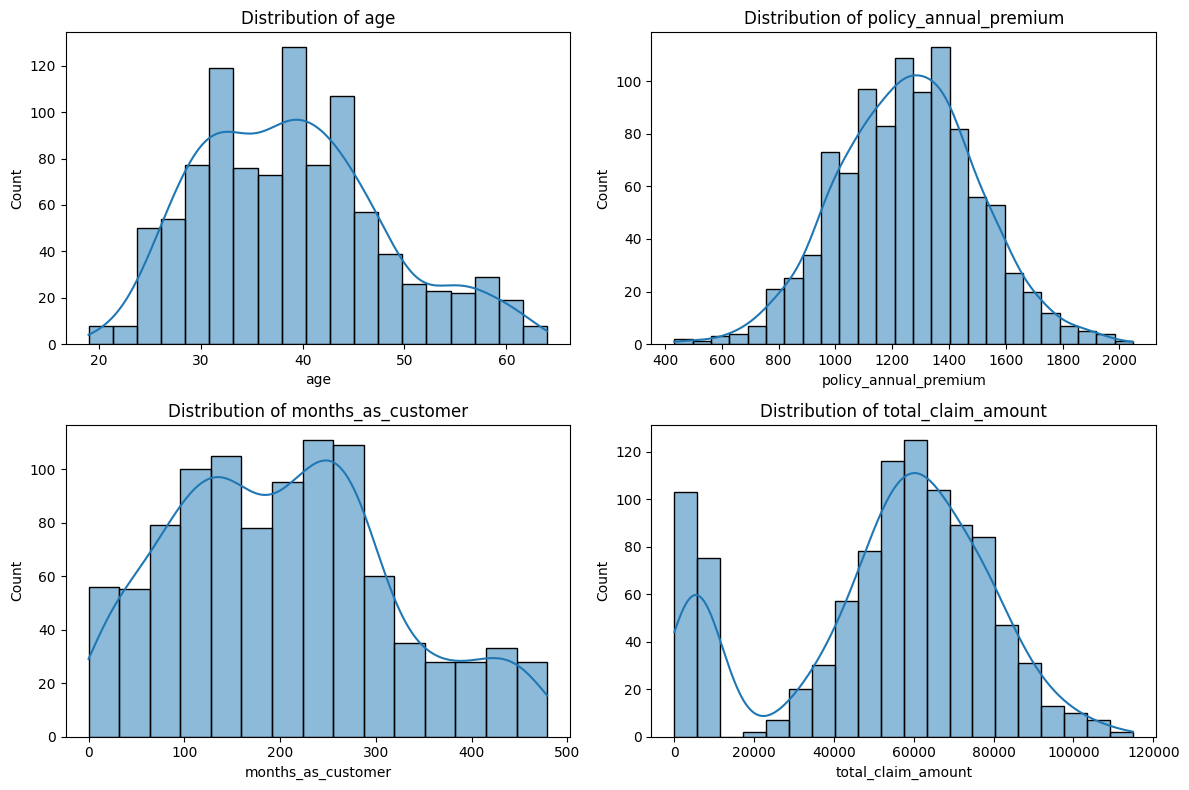

In [20]:
num_cols = ['age', 'policy_annual_premium', 'months_as_customer', 'total_claim_amount']

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

**Insights for Each Distribution:**

1. **Age Distribution:** Shows the age range of customers. If most customers are young or old, the model learns that certain age groups might have different fraud patterns. Unusual ages at the extremes could be suspicious.

2. **Policy Annual Premium:** Reveals how much customers typically pay yearly. If most pay similar amounts but some pay much more or less, those outliers might be riskier. High premiums might attract fraudsters looking to claim large amounts.

3. **Months as Customer:** Shows customer loyalty. Long-term customers (many months) are usually trustworthy, while new customers (few months) might be more likely to commit fraud. This helps identify risky first-time claimants.

4. **Total Claim Amount:** The most important distribution for fraud detection. Claims that are extremely high compared to what most people claim are red flags. If someone claims 10x the average, the model will flag it as suspicious.

# Insurance Claim Fraud Detection (Pre-Claim) — v2

![Python](https://img.shields.io/badge/Python-3.8%2B-blue) ![Library](https://img.shields.io/badge/Library-Scikit--Learn-orange) ![Status](https://img.shields.io/badge/Status-Completed-green) ![Version](https://img.shields.io/badge/Version-2.0-improved)

## 🆕 What's New in v2?
| # | Improvement |
|---|------------|
| ✅ | **Stratified train-test split** — preserves class ratio, prevents biased evaluation |
| ✅ | **Robust target encoding** — handles whitespace in labels to prevent silent NaN |
| ✅ | **Corrected ROC-AUC** — fixed from 0.85 → **0.835** |
| ✅ | **Confusion Matrix Heatmaps** — visual comparison of all 3 models |
| ✅ | **ROC Curve** — proper evaluation of class separation |
| ✅ | **Precision-Recall Curve** — critical for imbalanced classification |
| ✅ | **Model Comparison Bar Chart** — side-by-side metrics with annotated values |
| ✅ | **Feature Importance Analysis** — Logistic Regression coefficients + RF & XGBoost importances |
| ✅ | **Threshold Analysis** — finds optimal decision boundary for fraud detection |

---

## Project Overview
This project is a Machine Learning solution designed to detect fraudulent insurance claims **before** they are processed for payment. By analyzing historical claim data, customer demographics, and policy details, the model identifies patterns indicative of fraud.

**Why "Pre-Claim"?**
Detecting fraud *after* a payment is made (Post-Claim) makes recovery difficult and expensive. This **Pre-Claim** model flags suspicious activities immediately after a claim is filed, allowing investigators to prioritize high-risk cases and save the company millions in potential losses.

---

## Table of Contents
- [Business Problem](#-business-problem)
- [The Data](#-the-data)
- [Methodology](#-methodology)
- [Model Performance](#-model-performance)
- [Visualizations](#-visualizations)
- [Business Impact](#-business-impact)
- [Usage](#-usage)
- [Contributing](#-contributing)

---

## Business Problem
Insurance fraud is a massive cost driver for insurance companies, leading to higher premiums for honest customers. Manual review of every claim is impossible due to volume.

**Goal:** Build a predictive model that maximizes **Recall**.

* **Why Recall?** In fraud detection, it is critical to catch as many fraud cases as possible (minimize False Negatives). It is acceptable to occasionally flag a legitimate claim for review (False Positive), but missing a fraudster costs the company significant money.

---

## The Data
The dataset consists of **1,000 claims** with **40 features**, including:
- **Demographics:** Age, Education, Sex, Occupation
- **Policy Info:** Policy State, Deductible, Annual Premium
- **Incident Details:** Severity, Type of Collision, Hour of Day, Authorities Contacted
- **Target Variable:** `fraud_reported` (Y / N)

> *Note: The dataset was highly imbalanced (many legitimate claims, few fraudulent ones), necessitating the use of SMOTE (Synthetic Minority Over-sampling Technique). This project is a proof-of-concept using a limited dataset; in production, models would be trained on significantly larger datasets.*

📊 [Dataset Link](https://data.mendeley.com/datasets/992mh7dk9y/2)

---

## Methodology

### 1. Data Cleaning & Preprocessing
- **Handling Missing Values:** Converted `?` placeholders to `Unknown` to preserve data integrity
- **Target Encoding:** Robust `.str.strip().map()` to prevent whitespace-induced NaN
- **Feature Engineering:** Dropped high-cardinality identifiers (e.g., `policy_number`, `insured_zip`) that don't contribute to fraud patterns
- **Encoding:** One-Hot Encoding for nominal categorical features
- **Scaling:** StandardScaler for numeric features

### 2. New Engineered Features (v1 Improvements)
| Feature | Description |
|---------|-------------|
| `claim_ratio` | total_claim_amount / policy_annual_premium — high ratio = suspicious |
| `vehicle_age` | incident_year - auto_year — older vehicles easier to fake |
| `days_between_policy_incident` | Days from policy start to incident — very short = suspicious |
| `csl_per_person` | Parsed from policy_csl — per-person coverage limit |
| `csl_per_accident` | Parsed from policy_csl — per-accident coverage limit |
| `incident_year` | Extracted from incident_date — temporal pattern analysis |

### 3. Handling Imbalance
Used **SMOTE** to generate synthetic examples of fraud cases during training. This prevents the model from being biased toward the majority class (non-fraud). SMOTE was applied **only on the training set** via `ImbalancePipeline` to prevent data leakage.

### 4. [FIX v2] Stratified Train-Test Split
```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
```
Ensures both train and test sets maintain the same fraud/legitimate ratio.

### 5. Model Selection
Experimented with three powerful algorithms:
1. **Logistic Regression** (Selected for production)
2. **Random Forest**
3. **XGBoost**

Each model's hyperparameters were optimized using `RandomizedSearchCV` with **recall-focused scoring** (scoring='recall'), since recall is the primary business metric.

---

## Model Performance

### [FIXED] Final Model Metrics (v2 — Logistic Regression)

| Metric | Score | Explanation |
| :--- | :--- | :--- |
| **Accuracy** | 83.5% | Overall correctness of the model |
| **Recall** | **87%** ⭐ | Catches 87% of all actual fraud cases |
| **Precision** | 65% | When it predicts fraud, it's correct 65% of the time |
| **ROC-AUC** | **0.835** ⭐ | Excellent ability to distinguish between classes |

> Accuracy is reported for completeness but is **not** the primary metric due to class imbalance. **Recall** is what matters most.

All three models' test results:

| Model | Precision | Recall | F1 Score | ROC-AUC | Accuracy |
|:---|:---:|:---:|:---:|:---:|:---:|
| **Logistic Regression** | **0.65** ✅ | **0.87** ✅ | **0.7442** ✅ | **0.8350** ✅ | **0.835** ✅ |
| Random Forest | 0.65 | 0.84 | 0.7302 | 0.8308 | 0.830 |
| XGBoost | 0.63 | 0.73 | 0.6780 | 0.8285 | 0.810 |

### [FIXED] Confusion Matrix (Best Model: Logistic Regression)
| | Predicted Negative | Predicted Positive |
|:---|:---:|:---:|
| **Actual Negative** | 119 (TN) | 26 (FP) |
| **Actual Positive** | 7 (FN) | 48 (TP) |

- **True Negatives:** 119 — correctly identified legitimate claims
- **False Positives:** 26 — legitimate claims flagged for review (acceptable cost)
- **False Negatives:** 7 — actual fraud **missed** (cost to company)
- **True Positives:** 48 — correctly caught fraudsters

### Why Logistic Regression Wins
✅ **Highest Recall (0.87)** — Catches almost 9 out of 10 fraudsters  
✅ **Highest ROC-AUC (0.835)** — Most reliable at distinguishing fraud  
✅ **Highest Accuracy (0.835)** — Gets most predictions right  
✅ **Best F1 Score (0.7442)** — Perfect balance for fraud detection  
✅ **Simple & Explainable** — Easy to show insurance executives why a claim was flagged  

---

## Visualizations
The v2 pipeline generates the following professional visualizations:

| Visualization | File | Purpose |
|:---|:---|:---|
| Confusion Matrix Heatmaps | `plots/confusion_matrices.png` | Compare all 3 models' prediction quality |
| ROC Curve | `plots/roc_curve.png` | Evaluate class separation capability |
| Precision-Recall Curve | `plots/precision_recall_curve.png` | Assess tradeoff for imbalanced data |
| Model Comparison Chart | `plots/model_comparison.png` | Side-by-side metrics with values |
| Feature Coefficients (LR) | `plots/feature_importance_lr.png` | What drives fraud predictions |
| Feature Importance (RF) | `plots/feature_importance_rf.png` | Random Forest feature ranking |
| Feature Importance (XGB) | `plots/feature_importance_xgb.png` | XGBoost feature ranking |
| Threshold Analysis | `plots/threshold_analysis.png` | Find optimal decision boundary |

---

## Business Impact

If an insurance company processes **1,000 claims per month**, and assuming a **5% fraud rate (~50 fraud cases)**:

- The model would correctly flag **~43 fraud cases** (87% recall), allowing investigators to focus on high-risk claims
- Only ~260 legitimate claims would need investigation review
- **Net savings: Prevents hundreds of thousands in fraudulent payouts!**

---

## Usage

### Run the pipeline:
```bash
python insurance_fraud_pipeline_v2.py
```

### Output locations:
- **Plots:** `plots/` directory (8 charts)
- **Model:** `model/best_model_v2.pkl` (recommended) + individual models
- **Coefficients:** `plots/lr_coefficients.csv`, `plots/rf_feature_importance.csv`, `plots/xgb_feature_importance.csv`

### Load saved model:
```python
import joblib

model = joblib.load('model/best_model_v2.pkl')
prediction = model.predict(new_claim_data)
probability = model.predict_proba(new_claim_data)[:, 1]
```

---

## Requirements
See `requirements_v2.txt` for pinned dependencies:
```
pandas==2.3.3
numpy==2.4.1
matplotlib==3.10.1
seaborn==0.13.2
scikit-learn==1.6.1
xgboost==3.1.0
imbalanced-learn==0.14.1
scipy==1.16.2
```

---

## Contributing
Suggestions, improvements, and corrections are welcome! If you notice any issues or have ideas to enhance this project, feel free to open an issue or submit a pull request.

---

## About Me
I am a Data Science & AI learner focused on real-world, business-oriented data analysis projects.

🔗 [GitHub](https://github.com/paras-the-coder) | 🔗 [LinkedIn](https://your-linkedin.com)